# Targeted Carlini-Wagner (CW) Attack

This notebook demonstrates the targeted Carlini-Wagner attack on Whisper.

**Goal:** Modify an audio sample so Whisper outputs a *specific target phrase* instead of the original content.

**Method:**
1.  Initialize perturbation (random noise).
2.  Optimize perturbation to minimize $L_2$ distance from original audio.
3.  Optimize perturbation to *maximize* the log-probability of the target tokens.
4.  Apply constraints.

In [ ]:

import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt 
import jiwer


from IPython.display import Audio, display


from src.models.whisper_wrapper import WhisperASRWithAttack
import src.attacks as attacks
import src.data as data_loader


torch.manual_seed(42)
np.random.seed(42)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [2]:

model_name = "openai/whisper-small"

audio_ds = data_loader.load_dataset()
model = WhisperASRWithAttack(device=device)
print(f"Loaded {len(audio_ds)} samples")


Found 2620 audio files.
Sample: /Users/victorhugogermano/Development/soundfinal/data/LibriSpeech/test-clean/61/70970/61-70970-0040.flac


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loaded 2620 samples


In [3]:
def get_ground_truth(audio_path: Path):
    # LibriSpeech structure: test-clean/speaker/chapter/file.flac
    # Trans file: test-clean/speaker/chapter/speaker-chapter.trans.txt
    chapter_dir = audio_path.parent
    speaker_id = audio_path.parts[-3]
    chapter_id = audio_path.parts[-2]
    trans_file = chapter_dir / f"{speaker_id}-{chapter_id}.trans.txt"
    
    if not trans_file.exists():
        return None
        
    with open(trans_file, 'r') as f:
        for line in f:
            parts = line.split()
            if parts[0] == audio_path.stem:
                return " ".join(parts[1:]).strip().lower()
    return None

In [4]:
audio_path = audio_ds[0]
ground_truth = get_ground_truth(Path(audio_path))
print(f"Ground Truth Transcription: {ground_truth}")
clean_audio, audio_tensor = data_loader.load_audio_tensor(audio_path)
print(f"Sample Rate: {data_loader.TARGET_SAMPLE_RATE} Hz, Audio Shape: {clean_audio.shape}")
display(Audio(audio_tensor, rate=data_loader.TARGET_SAMPLE_RATE))

Ground Truth Transcription: they regained their apartment apparently without disturbing the household of gamewell
Sample Rate: 16000 Hz, Audio Shape: (66640,)


In [5]:
# Define the target phrase Whisper should output after the attack
target_phrase = "hello world"
print(f"Target phrase : {target_phrase}")

# Instantiate CW attack
# - c=50.0   : enough force to override original speech semantics
# - steps=200: optimizer needs ~200 iterations to converge on ASR models
# - binary_search_steps=7: finds tightest c that succeeds
# - learning_rate=0.005 + cosine scheduler gives smoother convergence
cw_attack = attacks.CWAuditoryAttack(
    whisper_model=model,
    device=device,
    learning_rate=0.005,
    c=50.0,
    steps=100,
    binary_search_steps=7,
    early_stop_check_every=50,
)

# Run attack — returns 1-D adversarial tensor on CPU
adv_audio = cw_attack.attack(audio_tensor, target_phrase)


Target phrase : hello world

[CW] Binary-search round 1/7 | c=50.0000


/opt/homebrew/anaconda3/envs/capstone/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 3001, 201]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it w

    step    0/100 | ce=10.7882  l2=0.06672  pred='They regain their apartment, apparently, without disturbing the househ'
    step   50/100 | ce=1.3700  l2=18.32972  pred='hello, guys.hello,hello,hello,hello,hello,hello,hello,hello,hello,hell'
    step   99/100 | ce=0.6489  l2=18.00464  pred='hello world'
    ↳ early stop: target achieved with sufficient budget
  ✓ Succeeded  l2=18.00464

[CW] Binary-search round 2/7 | c=25.0000
    step    0/100 | ce=10.8892  l2=0.06638  pred='They regain their apartment, apparently, without disturbing the househ'
    step   50/100 | ce=0.9623  l2=16.84901  pred='hello world'
    ↳ early stop: target achieved with sufficient budget
  ✓ Succeeded  l2=16.31830

[CW] Binary-search round 3/7 | c=12.5000
    step    0/100 | ce=10.8411  l2=0.06609  pred='They regain their apartment, apparently, without disturbing the househ'
    step   50/100 | ce=0.8014  l2=11.80713  pred='hello world'
    ↳ early stop: target achieved with sufficient budget
  ✓ Succeeded 

In [6]:

# Save both versions for playback / evaluation
#sf.write("targeted_attack_clean.wav", clean_audio, samplerate=16000)
#sf.write("targeted_attack_adv.wav",   adv_audio.numpy(),   samplerate=16000)

snr = attacks.compute_snr(clean_audio, adv_audio.numpy())
print(f"\nSNR (clean vs adversarial): {snr:.2f} dB")


SNR (clean vs adversarial): 25.69 dB


  EVALUATION


/opt/homebrew/anaconda3/envs/capstone/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 3001, 201]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]
/opt/homebrew/anaconda3/envs/capstone/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 3001, 201]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse

Ground truth    : they regained their apartment apparently without disturbing the household of gamewell
Target phrase   : hello world

Clean prediction: They regain their apartment, apparently, without disturbing the household of Gainwell.
Adv. prediction : hello world

WER  (clean)    : 0.364
WER  (adv)      : 1.000
SNR             : 25.69 dB
Attack success  : YES ✓


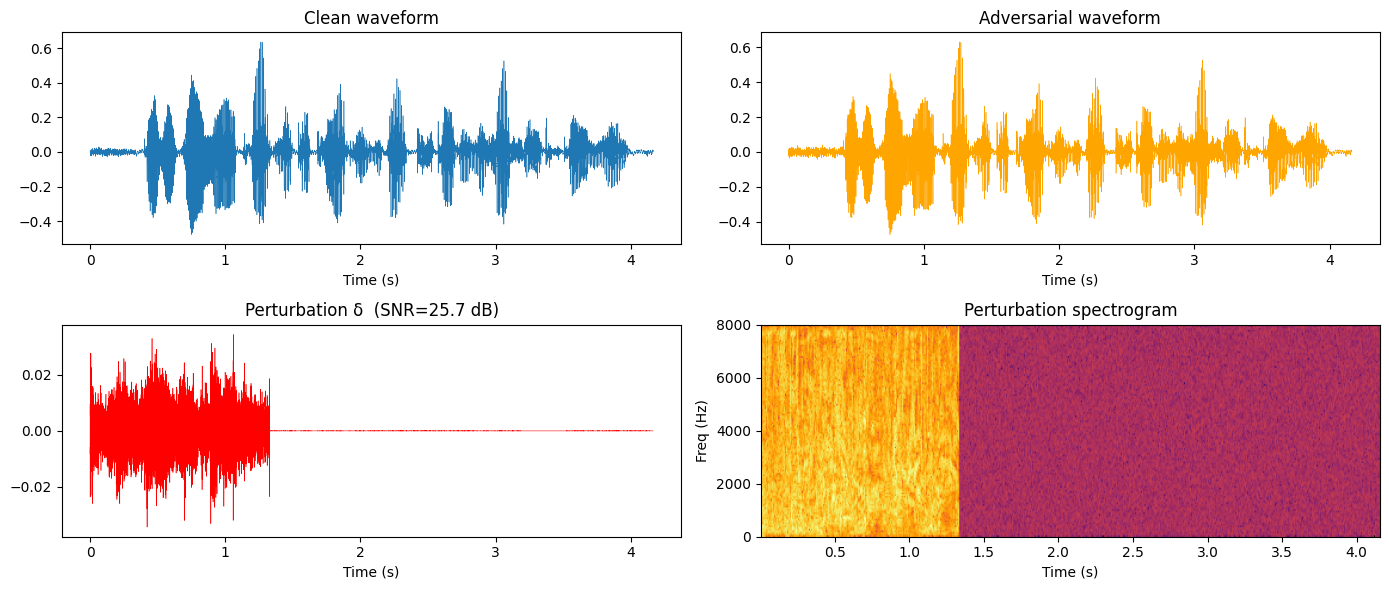


--- Playback ---
Clean:


Adversarial:


In [7]:
# Evaluate Results


print("=" * 55)
print("  EVALUATION")
print("=" * 55)

pred_clean = model.transcribe(audio_tensor)
pred_adv   = model.transcribe(adv_audio)

wer_clean = jiwer.wer(ground_truth, pred_clean.lower())
wer_adv   = jiwer.wer(ground_truth, pred_adv.lower())

attack_success = target_phrase.lower() in pred_adv.lower()

print(f"Ground truth    : {ground_truth}")
print(f"Target phrase   : {target_phrase}")
print()
print(f"Clean prediction: {pred_clean}")
print(f"Adv. prediction : {pred_adv}")
print()
print(f"WER  (clean)    : {wer_clean:.3f}")
print(f"WER  (adv)      : {wer_adv:.3f}")
print(f"SNR             : {snr:.2f} dB")
print(f"Attack success  : {'YES ✓' if attack_success else 'NO  ✗'}")
print("=" * 55)

# --- Waveform & spectrogram comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
t = np.linspace(0, len(audio_tensor) / 16000, len(audio_tensor))

axes[0, 0].plot(t, audio_tensor.numpy(), linewidth=0.4)
axes[0, 0].set_title("Clean waveform")
axes[0, 0].set_xlabel("Time (s)")

axes[0, 1].plot(t[:len(adv_audio)], adv_audio.numpy(), linewidth=0.4, color="orange")
axes[0, 1].set_title("Adversarial waveform")
axes[0, 1].set_xlabel("Time (s)")

delta_np = (adv_audio - audio_tensor[:len(adv_audio)]).numpy()
axes[1, 0].plot(t[:len(delta_np)], delta_np, linewidth=0.4, color="red")
axes[1, 0].set_title(f"Perturbation δ  (SNR={snr:.1f} dB)")
axes[1, 0].set_xlabel("Time (s)")

axes[1, 1].specgram(delta_np, Fs=16000, cmap="inferno")
axes[1, 1].set_title("Perturbation spectrogram")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Freq (Hz)")

plt.tight_layout()
plt.show()

print("\n--- Playback ---")
print("Clean:")
display(Audio(audio_tensor.numpy(), rate=16000))
print("Adversarial:")
display(Audio(adv_audio.numpy(), rate=16000))


### Observations
- Targeted attacks are significantly harder than untargeted attacks (which just try to break the model).
- The perturbation might be larger to successfully override the original semantic information.
- If `result_adv['text']` contains the target phrase, the attack is successful.

In [8]:
import random

# Batch evaluation — 5 utterances, single target phrase
N_SAMPLES = 5
TARGET    = "hello world"

# For batch runs use fewer binary-search rounds to keep runtime reasonable;
# increase binary_search_steps=7 for best quality.
batch_cw = attacks.CWAuditoryAttack(
    whisper_model=model,
    device=device,
    learning_rate=0.005,
    c=50.0,
    steps=100,
    binary_search_steps=3,
    early_stop_check_every=50,
)

random.seed(42)
sample_files = random.sample(list(audio_ds), min(N_SAMPLES, len(audio_ds)))
rows = []

for fp in sample_files:
    fp = Path(fp)
    _, audio = data_loader.load_audio_tensor(str(fp))

    # Ground truth
    tf = fp.parent / f"{fp.parent.parent.name}-{fp.parent.name}.trans.txt"
    gt = ""
    if tf.exists():
        with open(tf) as fh:
            for line in fh:
                uid, *words = line.strip().split()
                if uid == fp.stem:
                    gt = " ".join(words).lower()
                    break

    print(f"\n→ Attacking {fp.name}  (gt: '{gt[:60]}')")
    adv = batch_cw.attack(audio, TARGET)

    pred_c = model.transcribe(audio).lower()
    pred_a = model.transcribe(adv).lower()
    snr_i  = attacks.compute_snr(audio.numpy(), adv.numpy())
    succ   = TARGET in pred_a

    print(f"  clean='{pred_c[:60]}'  adv='{pred_a[:60]}'  SNR={snr_i:.1f}dB  {'✓' if succ else '✗'}")

    rows.append({
        "file"        : fp.name,
        "ground_truth": gt,
        "clean_pred"  : pred_c,
        "adv_pred"    : pred_a,
        "WER_clean"   : round(jiwer.wer(gt, pred_c), 3),
        "WER_adv"     : round(jiwer.wer(gt, pred_a), 3),
        "SNR_dB"      : round(snr_i, 2),
        "success"     : succ,
    })

results_df = pd.DataFrame(rows)
print("\n--- Batch Summary ---")
print(results_df[["file", "WER_clean", "WER_adv", "SNR_dB", "success"]].to_string(index=False))
print(f"\nAttack success rate : {results_df['success'].mean():.0%}")
print(f"Mean SNR            : {results_df['SNR_dB'].mean():.2f} dB")
print(f"Mean WER (clean)    : {results_df['WER_clean'].mean():.3f}")
print(f"Mean WER (adv)      : {results_df['WER_adv'].mean():.3f}")



→ Attacking 3570-5695-0014.flac  (gt: 'among the country population its place is to some extent tak')

[CW] Binary-search round 1/3 | c=50.0000
    step    0/100 | ce=9.2670  l2=0.16817  pred='Among the country population its places to some extent taken by saving'
    step   50/100 | ce=0.6562  l2=17.68007  pred='hello world'
    ↳ early stop: target achieved with sufficient budget
  ✓ Succeeded  l2=17.50562

[CW] Binary-search round 2/3 | c=25.0000
    step    0/100 | ce=9.1435  l2=0.16924  pred='Among the country population its places to some extent taken by saving'
    step   50/100 | ce=0.6558  l2=15.01181  pred='hello world'
    ↳ early stop: target achieved with sufficient budget
  ✓ Succeeded  l2=14.34047

[CW] Binary-search round 3/3 | c=12.5000
    step    0/100 | ce=9.2155  l2=0.17032  pred='Among the country population its places to some extent taken by saving'
    step   50/100 | ce=1.0693  l2=11.33736  pred='hello world'
    ↳ early stop: target achieved with sufficient b

## Plan: Carlini-Wagner Attack Presentation Script

This plan outlines the structure for a presentation script or evidence document explaining the `CWAuditoryAttack` implementation. The presentation will break down the mathematical foundations of the attack, the structural components of the code, and the specific optimization strategies used to trick the Whisper ASR model while keeping audio perturbations imperceptible.

**Steps**
1. **Introduction & Objective**: Define the goal of the `CWAuditoryAttack` class in cw.py — performing a targeted adversarial attack on the Whisper model by finding the smallest possible distortion that causes specific mis-transcriptions.
2. **Mathematical Formulation**: Detail the core loss function found in the class docstring and inner loop: minimizing $||\delta||_2^2 + c \cdot \text{CE}(f(x + \delta), \text{target})$.
3. **The Outer Optimization (Binary Search)**: Explain the `attack` method in cw.py. Detail how it uses binary search over the regularisation constant `c` to find the bare minimum perturbation magnitude required for a successful attack.
4. **The Inner Optimization Loop**: Describe the `_run_inner_optimization` method in cw.py. Cover key techniques:
   - Initializing with random noise to escape flat gradients.
   - Using the Adam optimizer with a `CosineAnnealingLR` scheduler for smooth convergence.
   - Constraining the audio waveform strictly using `torch.clamp(..., -1.0, 1.0)` to prevent clipping artifacts.
5. **Practical Enhancements (Early Stopping & Batching)**: Highlight efficiency features, such as periodic Whisper transcriptions for early stopping and the sequential `batch_attack` wrapper in cw.py that prevents consumer GPUs from running out of memory.

**Verification**
The generated text should precisely map to the implemented features and parameters in `cw.py`, such as the early stopping budget, cosine annealing, and binary round logs.

**Decisions**
- The document will be formatted logically as a script/technical report (Introduction -> Theory -> Implementation -> Optimizations) so it can be directly read or presented to a technical audience.

The Carlini-Wagner (CW) attack is a highly effective adversarial algorithm designed to fool machine learning models. In this context, it subtly modifies an audio file so that a human hears the original sound, but the AI transcription model (Whisper) hears a specific, hidden "target phrase."

Here is an explanation of how the script implements the algorithm, breaking down the complex concepts into simpler mechanics.

### The Core Concept: The Balancing Act
The algorithm works by optimizing a mathematical equation called a "loss function." The CW attack constantly balances two opposing goals:
1.  **Be Sneaky (Minimize L2 Penalty):** The added noise (`delta`) must be as quiet and unnoticeable as possible.
2.  **Be Effective (Cross-Entropy Loss):** The added noise *must* force the AI to transcribe the chosen `target_phrase`.

The formula looks like this:
`Total Loss = [Size of Noise] + c * [Failure to Fool the AI]`

### The Magic Constant: `c` and Binary Search
The variable `c` determines which of the two goals is more important. 
* If `c` is too small, the algorithm prioritizes silence, and the AI isn't fooled.
* If `c` is too large, the AI is fooled, but the audio sounds like loud static.

Instead of guessing the perfect `c`, the algorithm uses a **Binary Search**:
1. It tries a value for `c`.
2. If the attack succeeds, it lowers `c` (trying to make the noise quieter).
3. If the attack fails, it raises `c` (making the noise louder to force the AI to break).
4. It repeats this back and forth until it finds the lowest possible `c` that still fools the AI.

### Step-by-Step Optimization Loop
Inside each binary search round, the `_run_inner_optimization` method executes the attack step-by-step:

1.  **Random Start (`noise_init`):** It adds a microscopic amount of random static to the audio. This "knocks" the optimizer out of stagnant mathematical flatlines so it can start learning.
2.  **The Optimization Loop:** It uses a mathematical tracker (Adam Optimizer) to adjust the noise slightly over hundreds of steps (`self.steps`).
3.  **Audio Clipping (`torch.clamp`):** Digital audio must stay between `-1.0` and `1.0`. If the noise pushes the audio beyond this limit, it creates a loud "crackling" sound. The `clamp` function rigidly enforces these bounds to keep the audio sounding natural.
4.  **Learning Rate Schedule (`CosineAnnealingLR`):** The optimizer takes large steps at the beginning and smaller, more precise steps toward the end, ensuring it hones in perfectly on the exact required noise profile.
5.  **Periodic Checking and Early Stopping:** Transcribing audio is slow. Instead of checking if the AI is fooled on every single step, it checks every `N` steps (`early_stop_check_every`). Once the AI outputs the target phrase, and a minimum budget of steps has passed, the loop gracefully stops to save processing time.

### Summary
The script loops through different "strengths" of attacks (binary search). Inside each try, it sculpts random static into a precise frequency pattern that sounds like background hiss to humans, but exactly matches the mathematical features of the `target_phrase` for the Whisper model.